# ERCOT Energy Procurement Value Analysis

**Objective:** Quantify the dollar savings a utility serving the ERCOT (Texas) grid would realize by using our bias-correction neural network instead of raw NWP forecasts for day-ahead electricity procurement.

**Comparisons:**
- **NN** (our bias-corrected neural network)
- **Best individual NWP model** (selected by lowest ERCOT-wide MAE)
- **NWP ensemble mean** (average of all 6 models)

**Methodology:**
1. Map model cities to ERCOT load centers (Houston, Dallas, San Antonio, Austin)
2. Population-weight city forecasts to get an ERCOT-wide temperature
3. Compute load forecast error = (forecast - actual) x sensitivity (MW/degF)
4. Cost of error = |load_error| x DA-RT spread x peak hours
5. Savings = NWP cost - NN cost

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "legend.fontsize": 10,
})

from energy_value import (
    run_ercot_analysis, sensitivity_analysis,
    ERCOT_CITIES, DEFAULT_COOLING_THRESHOLD_F, NWP_DISPLAY_NAMES,
)
from economic_data_prep import load_test_with_nwp, NWP_COLS
import config as cfg

def dollar_fmt(x, _):
    if abs(x) >= 1e6:
        return f"${x / 1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x / 1e3:.0f}K"
    return f"${x:.0f}"

print("Imports loaded successfully.")
print(f"Test period: {cfg.TEST_START} to {cfg.TEST_END}")

Imports loaded successfully.
Test period: 2025-04-17 to 2026-04-16


In [2]:
df = load_test_with_nwp()

## 2. ERCOT City Mapping

The four ERCOT load centers are population-weighted to approximate grid-wide temperature exposure.

| City | Ticker | Population Weight | Rationale |
|------|--------|:-----------------:|-----------|
| Houston | `KXHIGHTHOU` | 0.35 | Largest metro, highest load share |
| Dallas | `KXHIGHTDAL` | 0.30 | Second-largest metro |
| San Antonio | `KXHIGHTSATX` | 0.20 | Third-largest |
| Austin | `KXHIGHAUS` | 0.15 | Smallest of the four |

Weights sum to 1.0. The population-weighted average temperature is used as the ERCOT-wide forecast.

In [3]:
city_names = {
    "KXHIGHTHOU": "Houston",
    "KXHIGHTDAL": "Dallas",
    "KXHIGHTSATX": "San Antonio",
    "KXHIGHAUS": "Austin",
}
mapping_df = pd.DataFrame([
    {"City": city_names[t], "Ticker": t, "Weight": w}
    for t, w in ERCOT_CITIES.items()
])
mapping_df

,City,Ticker,Weight
0,Houston,KXHIGHTHOU,0.35
1,Dallas,KXHIGHTDAL,0.30
2,San Antonio,KXHIGHTSATX,0.20
3,Austin,KXHIGHAUS,0.15


## 3. Identify Best Individual NWP Model

Compare all 6 individual NWP models on ERCOT-wide population-weighted MAE to find the strongest single-model baseline.

ERCOT-Wide Population-Weighted MAE by Model:
 Rank         Model  ERCOT MAE (degF)
    1            NN          1.293554
    2          ICON          1.749932
    3           GFS          1.755767
    4           GEM          1.916959
    5 Ensemble Mean          2.023685
    6          HRRR          2.490548
    7         ECMWF          2.864479
    8           JMA          4.607740


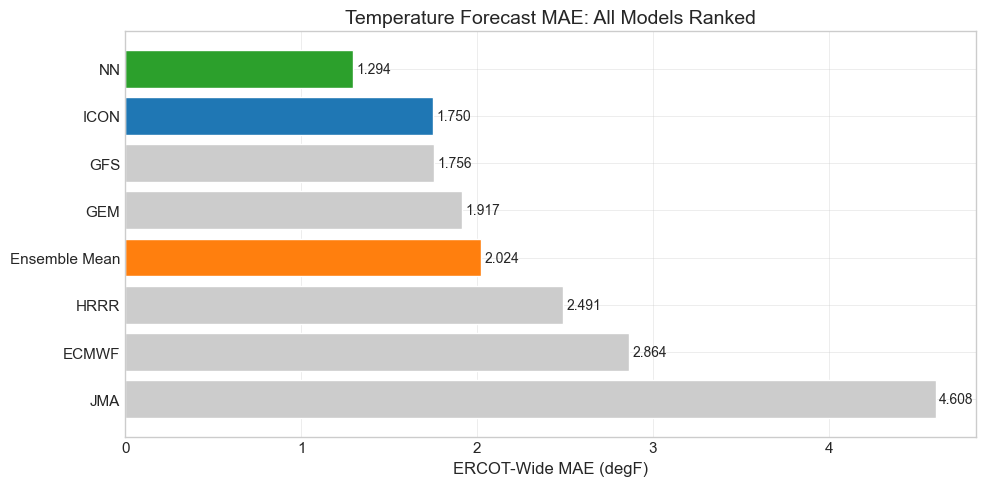

In [4]:
ercot_df = df[df["ticker"].isin(ERCOT_CITIES)].copy()
ercot_df["weight"] = ercot_df["ticker"].map(ERCOT_CITIES)

model_maes = {}
for col in NWP_COLS:
    weighted_err = (np.abs(ercot_df[col] - ercot_df["y_true"]) * ercot_df["weight"])
    daily_mae = weighted_err.groupby(ercot_df["date"]).sum() / ercot_df.groupby("date")["weight"].sum()
    model_maes[NWP_DISPLAY_NAMES[col]] = daily_mae.mean()

nn_weighted = (np.abs(ercot_df["mu"] - ercot_df["y_true"]) * ercot_df["weight"])
nn_daily = nn_weighted.groupby(ercot_df["date"]).sum() / ercot_df.groupby("date")["weight"].sum()
model_maes["NN"] = nn_daily.mean()

ens_weighted = (np.abs(ercot_df["nwp_ensemble_mean"] - ercot_df["y_true"]) * ercot_df["weight"])
ens_daily = ens_weighted.groupby(ercot_df["date"]).sum() / ercot_df.groupby("date")["weight"].sum()
model_maes["Ensemble Mean"] = ens_daily.mean()

mae_df = pd.DataFrame(
    [{"Model": k, "ERCOT MAE (degF)": v} for k, v in model_maes.items()]
).sort_values("ERCOT MAE (degF)")
mae_df["Rank"] = range(1, len(mae_df) + 1)

nwp_only = {k: v for k, v in model_maes.items() if k not in ("NN", "Ensemble Mean")}
best_nwp_name = min(nwp_only, key=nwp_only.get)
best_nwp_col = [col for col, name in NWP_DISPLAY_NAMES.items() if name == best_nwp_name][0]

print("ERCOT-Wide Population-Weighted MAE by Model:")
print(mae_df[["Rank", "Model", "ERCOT MAE (degF)"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = []
for m in mae_df["Model"]:
    if m == "NN":
        colors.append("#2ca02c")
    elif m == best_nwp_name:
        colors.append("#1f77b4")
    elif m == "Ensemble Mean":
        colors.append("#ff7f0e")
    else:
        colors.append("#cccccc")
ax.barh(mae_df["Model"], mae_df["ERCOT MAE (degF)"], color=colors, edgecolor="white")
ax.set_xlabel("ERCOT-Wide MAE (degF)")
ax.set_title("Temperature Forecast MAE: All Models Ranked")
ax.invert_yaxis()
for i, (_, row) in enumerate(mae_df.iterrows()):
    ax.text(row["ERCOT MAE (degF)"] + 0.02, i, f"{row['ERCOT MAE (degF)']:.3f}",
            va="center", fontsize=10)
fig.tight_layout()
plt.show()

## 4. Run ERCOT Analysis (NN vs Best NWP vs Ensemble Mean)

In [5]:
daily = run_ercot_analysis(df)

daily[f"best_nwp_cost"] = daily[f"{best_nwp_col}_cost"]
daily[f"best_nwp_load_error_mw"] = daily[f"{best_nwp_col}_load_error_mw"]
daily["best_nwp_forecast"] = daily[best_nwp_col]
daily["savings_vs_best_nwp"] = daily["best_nwp_cost"] - daily["nn_cost"]
daily["cum_savings_vs_best_nwp"] = daily["savings_vs_best_nwp"].cumsum()
daily["savings_vs_ensemble"] = daily["nwp_cost"] - daily["nn_cost"]
daily["cum_savings_vs_ensemble"] = daily["cumulative_savings"]

print(f"\nDA-RT spread (real ERCOT HB_HOUSTON peak-hour):")
print(f"  Mean:   ${daily['da_rt_spread'].mean():.2f}/MWh")
print(f"  Median: ${daily['da_rt_spread'].median():.2f}/MWh")
print(f"  Std:    ${daily['da_rt_spread'].std():.2f}/MWh")
print(f"  Range:  ${daily['da_rt_spread'].min():.2f} to ${daily['da_rt_spread'].max():.2f}/MWh")
daily.head(10)


DA-RT spread (real ERCOT HB_HOUSTON peak-hour):
  Mean:   $2.86/MWh
  Median: $3.29/MWh
  Std:    $25.30/MWh
  Range:  $-228.07 to $304.09/MWh


,date,nn_forecast,nwp_forecast,actual,nn_sigma,fcst_gfs_global,fcst_ecmwf_ifs025,fcst_icon_seamless,fcst_gem_seamless,fcst_jma_seamless,...,fcst_gem_seamless_cost,fcst_jma_seamless_cost,fcst_ncep_hrrr_conus_cost,best_nwp_cost,best_nwp_load_error_mw,best_nwp_forecast,savings_vs_best_nwp,cum_savings_vs_best_nwp,savings_vs_ensemble,cum_savings_vs_ensemble
0,2025-04-17,85.847809,85.426667,86.80,0.704317,86.655,85.615,86.285,86.520,82.895,...,21101.15000,294285.68125,166548.36250,38811.04375,-257.5,86.285,-32947.258645,-32947.258645,31737.814271,31737.814271
1,2025-04-18,88.421062,87.592500,89.00,0.677216,88.685,87.885,88.140,89.250,84.560,...,11578.12500,205627.50000,91004.06250,39828.75000,-430.0,88.140,13016.681133,-19930.577513,38372.774883,70110.589154
2,2025-04-19,81.628567,81.622500,82.15,0.824029,83.115,80.215,81.855,83.930,80.050,...,67789.07500,79975.87500,60172.32500,11234.70625,-147.5,81.855,-8623.436024,-28554.013537,231.035851,70341.625005
3,2025-04-20,83.194555,81.671667,83.40,0.742041,85.175,80.760,82.130,80.585,78.855,...,120668.49375,194827.10625,37507.96875,54440.13750,-635.0,82.130,45633.494471,17079.480934,65280.525721,135622.150725
4,2025-04-21,83.774068,82.011667,85.15,0.608123,84.645,80.360,83.020,81.510,79.025,...,60009.95000,100978.28125,27037.45000,35115.71250,-1065.0,83.020,12431.761772,29511.242706,29055.397189,164677.547914
5,2025-04-22,86.217969,84.522500,87.15,0.627243,86.265,83.190,84.915,85.435,81.160,...,91990.45625,321296.11250,52565.97500,119882.60625,-1117.5,84.915,69889.627380,99400.870086,90942.836755,255620.384669
6,2025-04-23,80.555663,80.317500,80.35,0.756555,83.550,78.275,79.470,82.180,78.460,...,44823.56250,46293.18750,9307.62500,21554.50000,-440.0,79.470,16517.039841,115917.909927,-4241.413284,251378.971385
7,2025-04-24,80.709476,80.240833,80.90,0.750119,81.260,78.180,80.880,82.010,78.830,...,42880.68750,79966.68750,23758.21875,772.62500,-10.0,80.880,-6587.536959,109330.372968,18104.270333,269483.241718
8,2025-04-25,83.929885,82.875833,85.05,0.687804,84.590,82.020,83.155,83.400,81.190,...,122512.50000,286605.00000,159637.50000,140703.75000,-947.5,83.155,57535.225470,166865.598439,78263.350470,347746.592189
9,2025-04-26,85.166079,83.561667,84.90,0.719453,85.470,82.400,84.035,84.955,80.030,...,1106.60000,97984.40000,8450.40000,17403.80000,-432.5,84.035,12050.300437,178915.898876,21573.767104,369320.359292


## 5. Summary Statistics: NN vs Best NWP vs Ensemble Mean

In [6]:
AUSTIN_ENERGY_SHARE = 0.20

nn_mae = np.abs(daily["nn_forecast"] - daily["actual"]).mean()
nwp_mae = np.abs(daily["nwp_forecast"] - daily["actual"]).mean()
best_nwp_mae = np.abs(daily["best_nwp_forecast"] - daily["actual"]).mean()

ercot_df = df[df["ticker"].isin(ERCOT_CITIES)].copy()
city_mae = ercot_df.groupby("ticker").apply(
    lambda g: pd.Series({
        "NN MAE (F)": np.abs(g["mu"] - g["y_true"]).mean(),
        f"{best_nwp_name} MAE (F)": np.abs(g[best_nwp_col] - g["y_true"]).mean(),
        "Ensemble MAE (F)": np.abs(g["nwp_ensemble_mean"] - g["y_true"]).mean(),
    }),
    include_groups=False,
)
city_names = {
    "KXHIGHTHOU": "Houston", "KXHIGHTDAL": "Dallas",
    "KXHIGHTSATX": "San Antonio", "KXHIGHAUS": "Austin",
}
city_mae["City"] = city_mae.index.map(city_names)
city_mae["NN vs Best NWP (F)"] = city_mae[f"{best_nwp_name} MAE (F)"] - city_mae["NN MAE (F)"]
city_mae["NN vs Ensemble (F)"] = city_mae["Ensemble MAE (F)"] - city_mae["NN MAE (F)"]
print("Temperature MAE by ERCOT City:")
print(city_mae[["City", "NN MAE (F)", f"{best_nwp_name} MAE (F)", "Ensemble MAE (F)",
                "NN vs Best NWP (F)", "NN vs Ensemble (F)"]].to_string(index=False))

nn_total_cost = daily["nn_cost"].sum()
nwp_total_cost = daily["nwp_cost"].sum()
best_nwp_total_cost = daily["best_nwp_cost"].sum()
savings_vs_ensemble = daily["savings_vs_ensemble"].sum()
savings_vs_best = daily["savings_vs_best_nwp"].sum()
total_days = len(daily)
pos_days_ens = (daily["savings_vs_ensemble"] > 0).sum()
pos_days_best = (daily["savings_vs_best_nwp"] > 0).sum()

summer = daily[(daily["month"] >= 6) & (daily["month"] <= 9)]
non_summer = daily[~((daily["month"] >= 6) & (daily["month"] <= 9))]

summary = pd.DataFrame({
    "Metric": [
        "ERCOT MAE (degF)",
        f"NN MAE improvement (degF)",
        f"NN MAE improvement (%)",
        "Annual procurement cost",
        "NN annual savings",
        "Austin Energy savings (20%)",
        "Days with positive savings",
        "Summer savings (Jun-Sep)",
        "Non-summer savings",
    ],
    "NN": [
        f"{nn_mae:.2f}",
        "--",
        "--",
        f"${nn_total_cost:,.0f}",
        "--",
        "--",
        "--",
        "--",
        "--",
    ],
    f"{best_nwp_name} (best NWP)": [
        f"{best_nwp_mae:.2f}",
        f"{best_nwp_mae - nn_mae:.2f}",
        f"{(best_nwp_mae - nn_mae) / best_nwp_mae * 100:.1f}%",
        f"${best_nwp_total_cost:,.0f}",
        f"${savings_vs_best:,.0f}",
        f"${savings_vs_best * AUSTIN_ENERGY_SHARE:,.0f}",
        f"{pos_days_best}/{total_days} ({pos_days_best/total_days*100:.1f}%)",
        f"${summer['savings_vs_best_nwp'].sum():,.0f}",
        f"${non_summer['savings_vs_best_nwp'].sum():,.0f}",
    ],
    "Ensemble Mean": [
        f"{nwp_mae:.2f}",
        f"{nwp_mae - nn_mae:.2f}",
        f"{(nwp_mae - nn_mae) / nwp_mae * 100:.1f}%",
        f"${nwp_total_cost:,.0f}",
        f"${savings_vs_ensemble:,.0f}",
        f"${savings_vs_ensemble * AUSTIN_ENERGY_SHARE:,.0f}",
        f"{pos_days_ens}/{total_days} ({pos_days_ens/total_days*100:.1f}%)",
        f"${summer['savings_vs_ensemble'].sum():,.0f}",
        f"${non_summer['savings_vs_ensemble'].sum():,.0f}",
    ],
})

print(summary.to_string(index=False))

Temperature MAE by ERCOT City:
       City  NN MAE (F)  ICON MAE (F)  Ensemble MAE (F)  NN vs Best NWP (F)  NN vs Ensemble (F)
     Austin    1.140913      3.048767          2.622603            1.907855            1.481690
     Dallas    1.015818      1.356164          1.525708            0.340346            0.509890
    Houston    1.683796      1.700548          2.549087            0.016752            0.865291
San Antonio    1.141714      1.452877          1.402009            0.311163            0.260295
                     Metric         NN ICON (best NWP)   Ensemble Mean
           ERCOT MAE (degF)       0.69            1.19            1.73
  NN MAE improvement (degF)         --            0.51            1.04
     NN MAE improvement (%)         --           42.5%           60.3%
    Annual procurement cost $9,524,023     $16,500,179     $23,499,437
          NN annual savings         --      $6,976,156     $13,975,414
Austin Energy savings (20%)         --      $1,395,231      $2,

## 6. Cumulative Savings Over Time

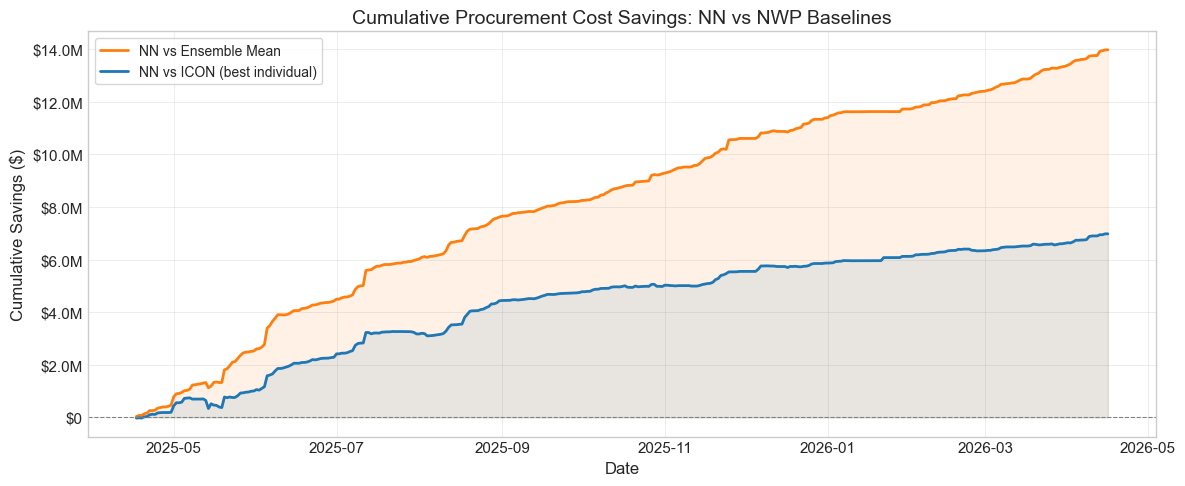

Final cumulative savings vs ensemble mean: $13,975,414
Final cumulative savings vs ICON:      $6,976,156


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["cum_savings_vs_ensemble"], color="#ff7f0e", lw=2,
        label=f"NN vs Ensemble Mean")
ax.plot(daily["date"], daily["cum_savings_vs_best_nwp"], color="#1f77b4", lw=2,
        label=f"NN vs {best_nwp_name} (best individual)")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.fill_between(daily["date"], 0, daily["cum_savings_vs_ensemble"],
                where=daily["cum_savings_vs_ensemble"] >= 0, alpha=0.10, color="#ff7f0e")
ax.fill_between(daily["date"], 0, daily["cum_savings_vs_best_nwp"],
                where=daily["cum_savings_vs_best_nwp"] >= 0, alpha=0.10, color="#1f77b4")
ax.set_title("Cumulative Procurement Cost Savings: NN vs NWP Baselines")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Savings ($)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
ax.legend(frameon=True, fancybox=True)
fig.tight_layout()
plt.show()

print(f"Final cumulative savings vs ensemble mean: ${daily['cum_savings_vs_ensemble'].iloc[-1]:,.0f}")
print(f"Final cumulative savings vs {best_nwp_name}:      ${daily['cum_savings_vs_best_nwp'].iloc[-1]:,.0f}")

## 7. Daily Load Error Comparison

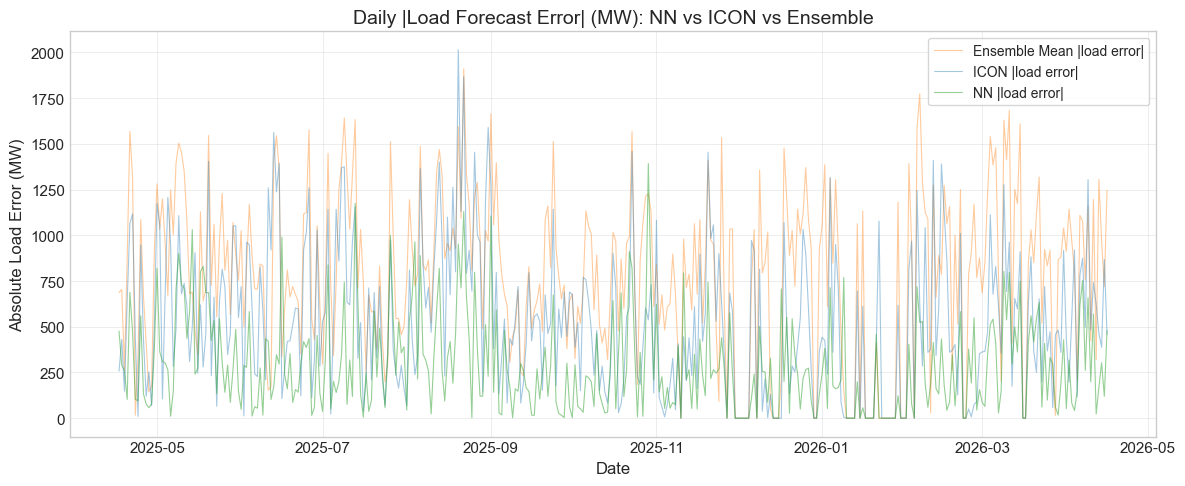

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["nwp_load_error_mw"].abs(), alpha=0.4,
        label="Ensemble Mean |load error|", color="#ff7f0e", lw=0.8)
ax.plot(daily["date"], daily["best_nwp_load_error_mw"].abs(), alpha=0.4,
        label=f"{best_nwp_name} |load error|", color="#1f77b4", lw=0.8)
ax.plot(daily["date"], daily["nn_load_error_mw"].abs(), alpha=0.5,
        label="NN |load error|", color="#2ca02c", lw=0.8)
ax.set_title(f"Daily |Load Forecast Error| (MW): NN vs {best_nwp_name} vs Ensemble")
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Load Error (MW)")
ax.legend(frameon=True, fancybox=True)
fig.tight_layout()
plt.show()

## 8. Monthly Savings

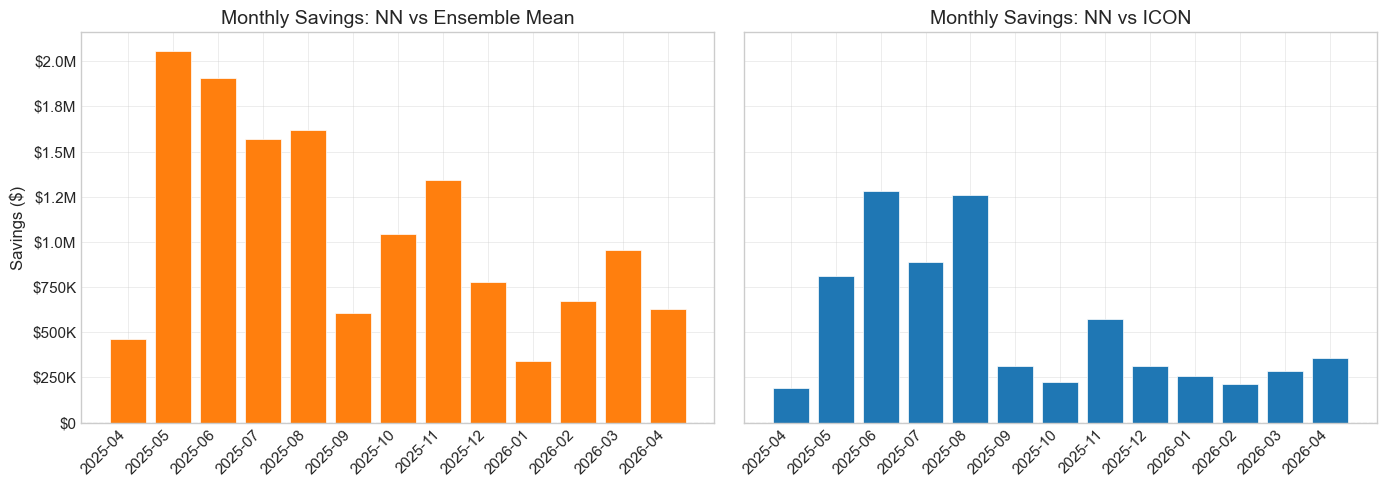

In [9]:
monthly_ens = daily.groupby(daily["date"].dt.to_period("M"))["savings_vs_ensemble"].sum()
monthly_best = daily.groupby(daily["date"].dt.to_period("M"))["savings_vs_best_nwp"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

colors = ["#ff7f0e" if v >= 0 else "#d62728" for v in monthly_ens.values]
axes[0].bar(range(len(monthly_ens)), monthly_ens.values, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_xticks(range(len(monthly_ens)))
axes[0].set_xticklabels([str(p) for p in monthly_ens.index], rotation=45, ha="right")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].set_title("Monthly Savings: NN vs Ensemble Mean")
axes[0].set_ylabel("Savings ($)")
axes[0].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

colors = ["#1f77b4" if v >= 0 else "#d62728" for v in monthly_best.values]
axes[1].bar(range(len(monthly_best)), monthly_best.values, color=colors, edgecolor="white", linewidth=0.5)
axes[1].set_xticks(range(len(monthly_best)))
axes[1].set_xticklabels([str(p) for p in monthly_best.index], rotation=45, ha="right")
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_title(f"Monthly Savings: NN vs {best_nwp_name}")

fig.tight_layout()
plt.show()

## 9. Savings vs Temperature (Cooling Days)

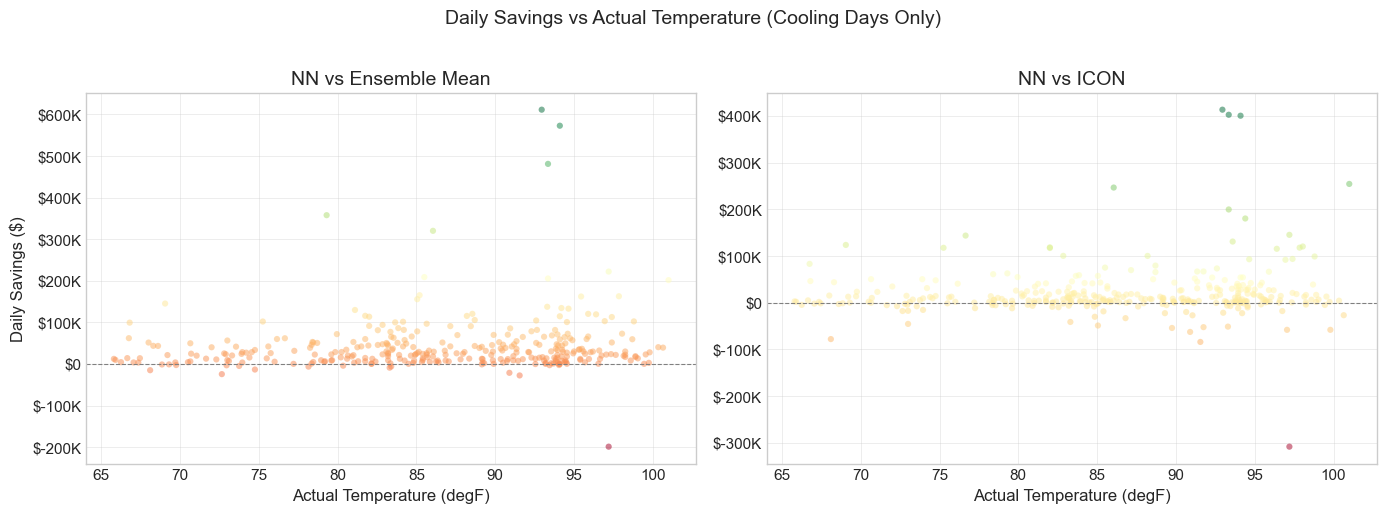

Cooling days (actual > 65.0 degF): 326/365


In [10]:
cooling_days = daily[daily["actual"] > DEFAULT_COOLING_THRESHOLD_F]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(cooling_days["actual"], cooling_days["savings_vs_ensemble"],
                       alpha=0.5, s=20, c=cooling_days["savings_vs_ensemble"],
                       cmap="RdYlGn", edgecolors="none")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].set_xlabel("Actual Temperature (degF)")
axes[0].set_ylabel("Daily Savings ($)")
axes[0].set_title("NN vs Ensemble Mean")
axes[0].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

sc1 = axes[1].scatter(cooling_days["actual"], cooling_days["savings_vs_best_nwp"],
                       alpha=0.5, s=20, c=cooling_days["savings_vs_best_nwp"],
                       cmap="RdYlGn", edgecolors="none")
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_xlabel("Actual Temperature (degF)")
axes[1].set_title(f"NN vs {best_nwp_name}")
axes[1].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

fig.suptitle("Daily Savings vs Actual Temperature (Cooling Days Only)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print(f"Cooling days (actual > {DEFAULT_COOLING_THRESHOLD_F} degF): {len(cooling_days)}/{len(daily)}")

## 10. Error Distribution: NN vs Best NWP vs Ensemble

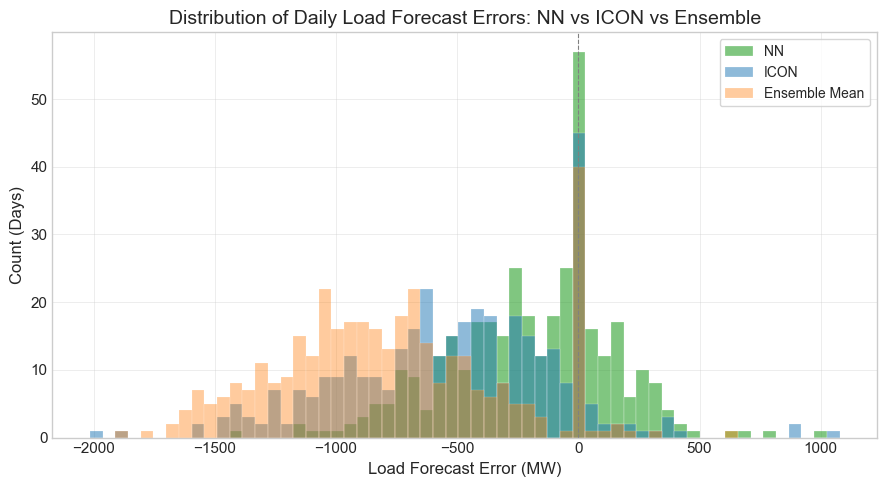

NN        load error std:       340 MW
ICON      load error std:       447 MW
Ensemble  load error std:       462 MW


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(
    min(daily["nn_load_error_mw"].min(), daily["nwp_load_error_mw"].min(),
        daily["best_nwp_load_error_mw"].min()),
    max(daily["nn_load_error_mw"].max(), daily["nwp_load_error_mw"].max(),
        daily["best_nwp_load_error_mw"].max()),
    60,
)
ax.hist(daily["nn_load_error_mw"], bins=bins, alpha=0.6, label="NN",
        color="#2ca02c", edgecolor="white", linewidth=0.3)
ax.hist(daily["best_nwp_load_error_mw"], bins=bins, alpha=0.5, label=best_nwp_name,
        color="#1f77b4", edgecolor="white", linewidth=0.3)
ax.hist(daily["nwp_load_error_mw"], bins=bins, alpha=0.4, label="Ensemble Mean",
        color="#ff7f0e", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Load Forecast Error (MW)")
ax.set_ylabel("Count (Days)")
ax.set_title(f"Distribution of Daily Load Forecast Errors: NN vs {best_nwp_name} vs Ensemble")
ax.legend(frameon=True, fancybox=True)
fig.tight_layout()
plt.show()

print(f"NN        load error std:  {daily['nn_load_error_mw'].std():>8,.0f} MW")
print(f"{best_nwp_name:9s} load error std:  {daily['best_nwp_load_error_mw'].std():>8,.0f} MW")
print(f"Ensemble  load error std:  {daily['nwp_load_error_mw'].std():>8,.0f} MW")

## 11. Sensitivity Analysis

Annual savings across a range of temperature-load sensitivities (MW/degF), all using real ERCOT prices.

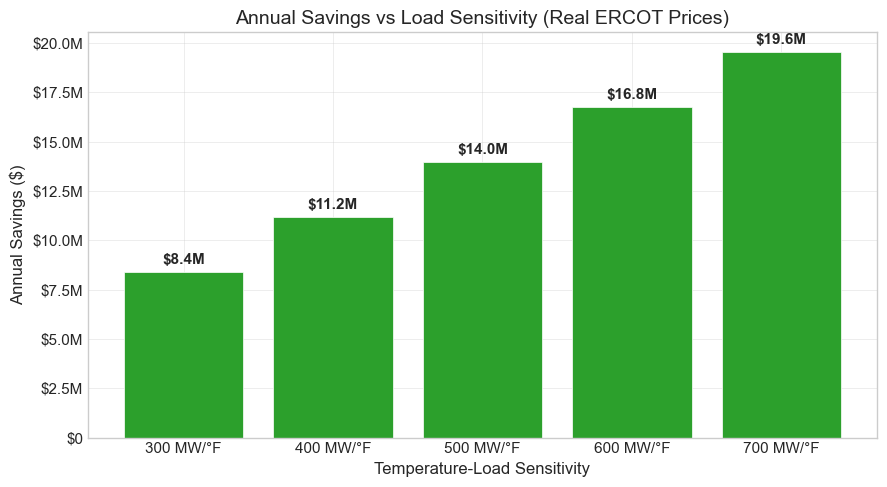

In [12]:
sens_df = sensitivity_analysis(df)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [f"{int(s)} MW/°F" for s in sens_df["sensitivity_mw_per_f"]],
    sens_df["annual_savings"],
    color="#2ca02c", edgecolor="white", linewidth=0.5,
)
for i, val in enumerate(sens_df["annual_savings"]):
    ax.text(i, val + sens_df["annual_savings"].max() * 0.02,
            f"${val / 1e6:.1f}M", ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Temperature-Load Sensitivity")
ax.set_ylabel("Annual Savings ($)")
ax.set_title("Annual Savings vs Load Sensitivity (Real ERCOT Prices)")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.show()

## 12. Parameter Assumptions

### Core Parameters

| Parameter | Value | Source / Rationale |
|-----------|-------|-------------------|
| **DA-RT spread** | Real ERCOT HB_HOUSTON settlement prices | Downloaded from ERCOT MIS (reportTypeId 13060/13061). Peak hours HE 13-20. No simulated or assumed spreads. |
| **Temperature-load sensitivity** | 500 MW/degF | ERCOT CDR reports; Considine (2000); Sailor & Munoz (1997). Represents the incremental MW of load per degree F above the cooling threshold. |
| **Cooling threshold** | 65 degF | Standard cooling degree day (CDD) base temperature. AC load ramps above this point. |
| **Peak hours** | 8 hours/day (HE 13-20) | Standard ERCOT peak window when temperature drives load. |
| **Population weights** | Houston 0.35, Dallas 0.30, San Antonio 0.20, Austin 0.15 | Proportional to metro population / load share in ERCOT. |

### Key Assumptions

1. **Real electricity prices** -- all DA-RT spreads come from actual ERCOT settlement data. No simulated or assumed price spreads are used.
2. **Linear temperature-demand relationship** above the cooling threshold. Real demand curves are slightly nonlinear, but the linear approximation is standard in the literature.
3. **Price-taking utility** -- the utility's procurement change does not affect wholesale prices.
4. **Only daily max temperature** -- real load forecasting uses hourly profiles, humidity, etc. Our analysis isolates the temperature channel only.
5. **Population-weighted city average approximates ERCOT-wide temperature** -- a simplification; ERCOT spans all of Texas.
6. **No capacity market or ancillary service value** -- only energy procurement savings are counted.
7. **Symmetric cost of error** -- both over- and under-forecasting incur costs.
8. **Best NWP model selected on full test period** -- in practice, the best model would not be known in advance. This gives the strongest possible single-model baseline.

### Data Sources

| Source | Description |
|--------|-------------|
| `model1_preds_test.parquet` | NN test set predictions (mu, sigma) for 20 US cities |
| NWP forecast CSVs | 6 raw NWP models (GFS, ECMWF, ICON, GEM, JMA, HRRR) |
| `data/ercot_prices.csv` | Real ERCOT HB_HOUSTON DAM/RTM settlement prices (via `fetch_ercot_prices.py`) |
| Test period | Apr 2025 - Apr 2026 |